# Step 2: Spin-up and the Atlantic overturning

Does the model's Atlantic overturning circulation (AMOC) settle to a steady state under the tutorial's forcing and surface restoring? In this notebook I read the 2000-year control spin-up, build an Atlantic basin mask, compute the Atlantic overturning streamfunction and an AMOC index, and check how much the model is still drifting at the end.

The spin-up was run with `scripts/run_experiment.sh` and the changed files in `experiments/spinup/`. The run itself lives in `~/mitgcm_runs/hosing/spinup/`, outside the repo.

I load the libraries and set the paths and constants. `MITgcmutils.rdmds` reads MITgcm's binary output files together with their `.meta` description files.

In [1]:
%matplotlib inline

import os
import glob

import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from MITgcmutils import rdmds

RUN = os.path.expanduser("~/mitgcm_runs/hosing/spinup")   # the spin-up run folder
STEPS_PER_YEAR = 360          # deltaTClock = 1 day, 360-day model year
SV = 1.0e6                    # 1 Sverdrup = 1e6 m^3/s
AMOC_LAT_MIN = 20.0           # AMOC index: maximum of the streamfunction between these latitudes ...
AMOC_LAT_MAX = 60.0
AMOC_DEPTH_MIN = 500.0        # ... and below this depth (m)
FINAL_YEARS = 100             # the "final state" is the mean of the last 100 years
FIG_DIR = "../figures"
DATA_DIR = "../data"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

I read the model grid. Tracer points (temperature, salinity) sit at cell centres (`XC`, `YC`). The meridional velocity sits on the southern face of each cell, at latitude `YG`, with face width `DXG` and open fraction `hFacS`.

In [2]:
xc = rdmds(os.path.join(RUN, "XC"))          # cell-centre longitude (deg E), shape (40, 90)
yc = rdmds(os.path.join(RUN, "YC"))          # cell-centre latitude (deg N)
yg = rdmds(os.path.join(RUN, "YG"))          # latitude of the southern cell faces, where v lives
dxg = rdmds(os.path.join(RUN, "DXG"))        # width of the southern face (m)
drf = rdmds(os.path.join(RUN, "DRF")).ravel()   # level thickness (m), 15 values
hfacc = rdmds(os.path.join(RUN, "hFacC"))    # open fraction of each tracer cell, shape (15, 40, 90)
hfacs = rdmds(os.path.join(RUN, "hFacS"))    # open fraction of each southern face
rac = rdmds(os.path.join(RUN, "RAC"))        # cell area (m^2)

ocean = hfacc[0] > 0                          # surface ocean points
lat_c = yc[:, 0]
lat_v = yg[:, 0]
z_interface = np.concatenate([[0.0], np.cumsum(drf)])   # depth of the level boundaries (m)
print("grid:", xc.shape, "levels:", len(drf), "| bottom of the deepest level:", z_interface[-1], "m")
print("ocean points at the surface:", ocean.sum())

grid: (40, 90) levels: 15 | bottom of the deepest level: 5200.0 m
ocean points at the surface: 2315


This is my first try at an Atlantic mask: every ocean point from 34°S northward, between 100°W (260°E) and 20°E. 34°S is roughly the latitude of the tip of Africa, and 20°E is the usual boundary with the Indian Ocean there.

In [3]:
atlantic_box = ocean & (yc >= -34.0) & ((xc >= 260.0) | (xc <= 20.0))

The box also catches Pacific points west of the Americas, because the Pacific coast of South and Central America is east of 100°W. I remove them with two rules I worked out from a map of the box: everything west of 290°E from 34°S to 10°N (off Chile, Peru, Ecuador and Colombia), and the points west of 270°E at 14°N (the Pacific side of Central America).

In [4]:
pacific_fix = np.zeros_like(ocean)
for j in range(len(lat_c)):
    for i in range(len(xc[0])):
        lon = xc[j, i]
        lat = lat_c[j]
        if lat <= 10.0 and 260.0 <= lon <= 290.0:
            pacific_fix[j, i] = True      # Pacific off South America and Panama
        if abs(lat - 14.0) < 0.1 and 260.0 <= lon <= 270.0:
            pacific_fix[j, i] = True      # Pacific side of Central America
atlantic = atlantic_box & ~pacific_fix
print("Atlantic points in the box:", atlantic_box.sum(), "| removed as Pacific:", (atlantic_box & pacific_fix).sum(),
      "| final Atlantic points:", atlantic.sum())

Atlantic points in the box: 537 | removed as Pacific: 77 | final Atlantic points: 460


I save the mask as a small text file (1 = Atlantic, 0 = not), so later notebooks use exactly the same mask.

In [5]:
np.savetxt(os.path.join(DATA_DIR, "atlantic_mask.csv"), atlantic.astype(int), fmt="%d", delimiter=",")
print("saved", os.path.join(DATA_DIR, "atlantic_mask.csv"), atlantic.shape)

saved ../data/atlantic_mask.csv (40, 90)


I plot the mask on a map to check it by eye. Blue cells are in my Atlantic mask, red cells are the Pacific points I removed.

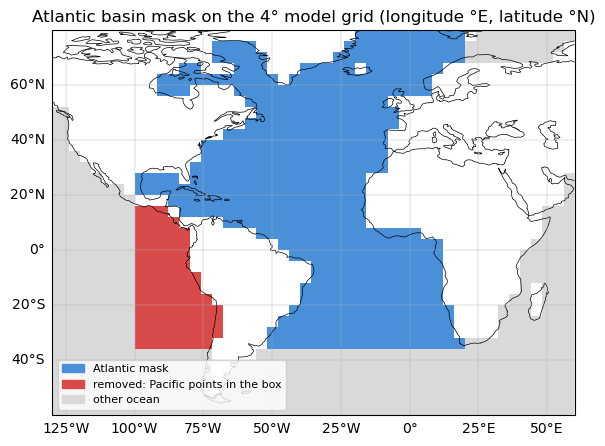

In [6]:
lon_edges = np.arange(0, 361, 4.0)
lat_edges = np.arange(-80, 81, 4.0)
show = np.full(ocean.shape, np.nan)
show[ocean] = 0
show[atlantic] = 1
show[atlantic_box & pacific_fix] = 2

fig = plt.figure(figsize=(9, 5))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=-40))
cmap = plt.matplotlib.colors.ListedColormap(["#d9d9d9", "#4a90d9", "#d94a4a"])
ax.pcolormesh(lon_edges, lat_edges, show, cmap=cmap, vmin=-0.5, vmax=2.5, transform=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.set_extent([-130, 60, -60, 80], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels=True, linewidth=0.3)
gl.top_labels = False
gl.right_labels = False
# Legend with one patch per category
for color, label in [("#4a90d9", "Atlantic mask"), ("#d94a4a", "removed: Pacific points in the box"), ("#d9d9d9", "other ocean")]:
    ax.fill([], [], color=color, label=label)
ax.legend(loc="lower left", fontsize=8)
ax.set_title("Atlantic basin mask on the 4° model grid (longitude °E, latitude °N)")
fig.savefig(os.path.join(FIG_DIR, "02_atlantic_mask.png"), dpi=150, bbox_inches="tight")
plt.show()

The meridional velocity sits between two tracer cells, so I count a v-point as Atlantic only when the cells on both sides are Atlantic.

In [7]:
atlantic_v = np.zeros_like(atlantic)
for j in range(1, len(lat_c)):
    atlantic_v[j, :] = atlantic[j, :] & atlantic[j - 1, :]
print("Atlantic v-points:", atlantic_v.sum())

Atlantic v-points: 404


This function computes the Atlantic overturning streamfunction from one 3D field of v. At each level and latitude I add up v times the face area across the Atlantic. Then I add up the transports from the surface downward, so the streamfunction at depth z is the total northward transport above z. That makes it positive for the AMOC cell, with northward flow near the surface and southward flow at depth, which is the usual convention. (My first version subtracted instead of adding, which flipped the sign; I caught it on the first plot.)

In [8]:
def atlantic_streamfunction(v):
    """Overturning streamfunction (Sv) at level boundaries, shape (16, 40)."""
    n_levels, n_lat, n_lon = v.shape
    transport = np.zeros((n_levels, n_lat))           # northward transport in each level (m^3/s)
    for k in range(n_levels):
        for j in range(n_lat):
            for i in range(n_lon):
                if atlantic_v[j, i]:
                    area = dxg[j, i] * drf[k] * hfacs[k, j, i]
                    transport[k, j] += v[k, j, i] * area
    psi = np.zeros((n_levels + 1, n_lat))
    for k in range(n_levels):
        psi[k + 1, :] = psi[k, :] + transport[k, :] / SV   # northward transport above this depth
    return psi


def amoc_index(psi):
    """Maximum of psi between AMOC_LAT_MIN and AMOC_LAT_MAX and below AMOC_DEPTH_MIN."""
    lat_ok = (lat_v >= AMOC_LAT_MIN) & (lat_v <= AMOC_LAT_MAX)
    depth_ok = z_interface >= AMOC_DEPTH_MIN
    region = psi[depth_ok, :][:, lat_ok]
    return region.max()

I find all annual-mean velocity files and compute the AMOC index for every model year. Each file is one year, labelled by the step number at the end of that year.

In [9]:
files = sorted(glob.glob(os.path.join(RUN, "vvel_annual.*.data")))
iterations = [int(os.path.basename(f).split(".")[1]) for f in files]
years = np.array(iterations) / STEPS_PER_YEAR
amoc = np.zeros(len(iterations))
for n in range(len(iterations)):
    v = rdmds(os.path.join(RUN, "vvel_annual"), iterations[n])
    amoc[n] = amoc_index(atlantic_streamfunction(v))
print(f"read {len(iterations)} annual means, model years {years[0]:.0f} to {years[-1]:.0f}")

read 2000 annual means, model years 1 to 2000


I save the AMOC index time series as a small CSV file in `data/`, so later steps (and anyone else) can use it without the raw output.

In [10]:
csv_path = os.path.join(DATA_DIR, "amoc_index_spinup.csv")
with open(csv_path, "w") as f:
    f.write("model_year,amoc_index_sv\n")
    for n in range(len(years)):
        f.write(f"{years[n]:.0f},{amoc[n]:.4f}\n")
print("saved", csv_path)

saved ../data/amoc_index_spinup.csv


For the final state I average the velocity over the last 100 years, then compute the streamfunction from that mean field.

In [11]:
n_final = min(FINAL_YEARS, len(iterations))
v_mean = np.zeros_like(rdmds(os.path.join(RUN, "vvel_annual"), iterations[-1]))
for it in iterations[-n_final:]:
    v_mean += rdmds(os.path.join(RUN, "vvel_annual"), it) / n_final
psi_final = atlantic_streamfunction(v_mean)

lat_ok = (lat_v >= AMOC_LAT_MIN) & (lat_v <= AMOC_LAT_MAX)
depth_ok = z_interface >= AMOC_DEPTH_MIN
masked = np.where(depth_ok[:, None] & lat_ok[None, :], psi_final, -np.inf)
k_max, j_max = np.unravel_index(np.argmax(masked), masked.shape)
print(f"final {n_final}-year mean AMOC index: {psi_final[k_max, j_max]:.2f} Sv "
      f"at {lat_v[j_max]:.0f}°N and {z_interface[k_max]:.0f} m depth")

final 100-year mean AMOC index: 19.80 Sv at 52°N and 1080 m depth


This figure shows the AMOC index for every year of the spin-up.

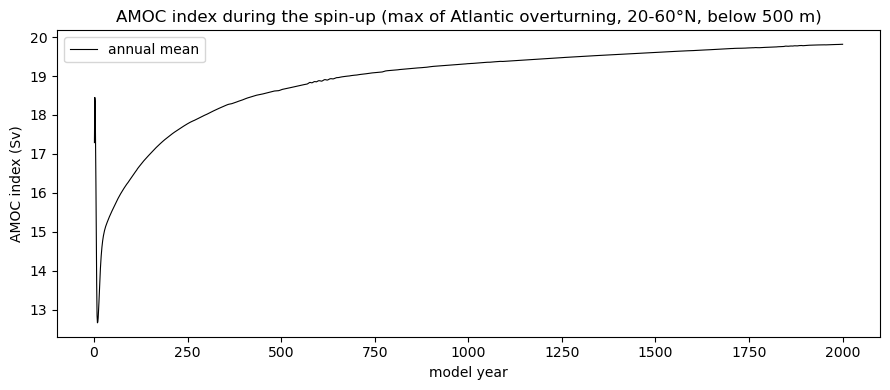

In [12]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(years, amoc, color="k", lw=0.8, label="annual mean")
ax.set_xlabel("model year")
ax.set_ylabel("AMOC index (Sv)")
ax.set_title(f"AMOC index during the spin-up (max of Atlantic overturning, {AMOC_LAT_MIN:.0f}-{AMOC_LAT_MAX:.0f}°N, below {AMOC_DEPTH_MIN:.0f} m)")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "02_amoc_index_spinup.png"), dpi=150)
plt.show()

This figure shows the final Atlantic overturning streamfunction against latitude and depth. Positive (red) means northward flow above that depth and southward flow below it, the sense of the AMOC.

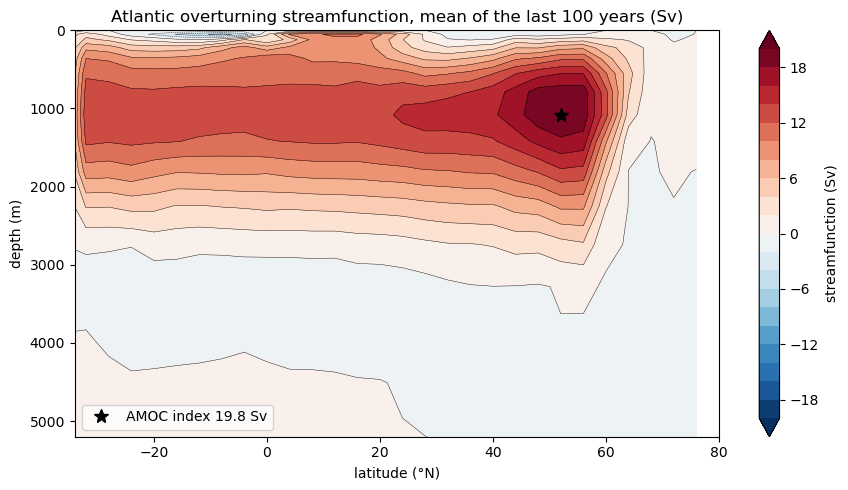

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
levels = np.arange(-20, 21, 2)
psi_plot = np.where(np.isfinite(psi_final), psi_final, np.nan)
cs = ax.contourf(lat_v, z_interface, psi_plot, levels=levels, cmap="RdBu_r", extend="both")
ax.contour(lat_v, z_interface, psi_plot, levels=levels, colors="k", linewidths=0.3)
ax.plot(lat_v[j_max], z_interface[k_max], "k*", ms=10, label=f"AMOC index {psi_final[k_max, j_max]:.1f} Sv")
ax.set_xlim(-34, 80)
ax.invert_yaxis()
ax.set_xlabel("latitude (°N)")
ax.set_ylabel("depth (m)")
ax.set_title(f"Atlantic overturning streamfunction, mean of the last {n_final} years (Sv)")
fig.colorbar(cs, ax=ax, label="streamfunction (Sv)")
ax.legend(loc="lower left")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "02_streamfunction_final.png"), dpi=150)
plt.show()

To judge whether the run has settled, I read the yearly global statistics file. Its level 0 is the volume mean of the whole ocean, so its change over time is the model drift.

In [14]:
def read_global_means(path, field):
    """Volume-mean value (level 0) of one field for every output time."""
    values = []
    iters = []
    current = None
    for line in open(path):
        if line.startswith(" field :"):
            parts = line.split()
            current = parts[2]
            it = int(line.split("Iter =")[1].split(";")[0])
        elif current == field and line.strip().startswith("0 "):
            values.append(float(line.split()[1]))
            iters.append(it)
    return np.array(iters) / STEPS_PER_YEAR, np.array(values)

stats_file = glob.glob(os.path.join(RUN, "ts_global_stats.*.txt"))[0]
yr_t, theta_mean = read_global_means(stats_file, "THETA")
yr_s, salt_mean = read_global_means(stats_file, "SALT")
print(f"global mean temperature: {theta_mean[0]:.4f} °C (year {yr_t[0]:.0f}) -> {theta_mean[-1]:.4f} °C (year {yr_t[-1]:.0f})")
print(f"global mean salinity:    {salt_mean[0]:.5f} g/kg -> {salt_mean[-1]:.5f} g/kg")

global mean temperature: 3.6171 °C (year 1) -> 4.4727 °C (year 2000)
global mean salinity:    34.71807 g/kg -> 34.72521 g/kg


I measure the drift at the end of the run as a straight-line trend over the last 500 years, for the AMOC index and the global means.

In [15]:
def trend_per_century(x, y, last_years):
    """Slope of a straight-line fit over the last `last_years` years, per 100 years."""
    keep = x >= x[-1] - last_years
    slope = np.polyfit(x[keep], y[keep], 1)[0]
    return slope * 100.0

TREND_YEARS = 500
print(f"trends over the last {TREND_YEARS} years:")
print(f"  AMOC index:         {trend_per_century(years, amoc, TREND_YEARS):+.3f} Sv per century")
print(f"  global mean T:      {trend_per_century(yr_t, theta_mean, TREND_YEARS):+.5f} °C per century")
print(f"  global mean S:      {trend_per_century(yr_s, salt_mean, TREND_YEARS):+.6f} g/kg per century")
print(f"  AMOC index, last {n_final} years: mean {amoc[-n_final:].mean():.2f} Sv, "
      f"year-to-year standard deviation {amoc[-n_final:].std():.3f} Sv")

trends over the last 500 years:
  AMOC index:         +0.042 Sv per century
  global mean T:      +0.00716 °C per century
  global mean S:      -0.001176 g/kg per century
  AMOC index, last 100 years: mean 19.80 Sv, year-to-year standard deviation 0.008 Sv


This figure shows the global mean temperature and salinity over the spin-up, to see how fast the deep ocean adjusts.

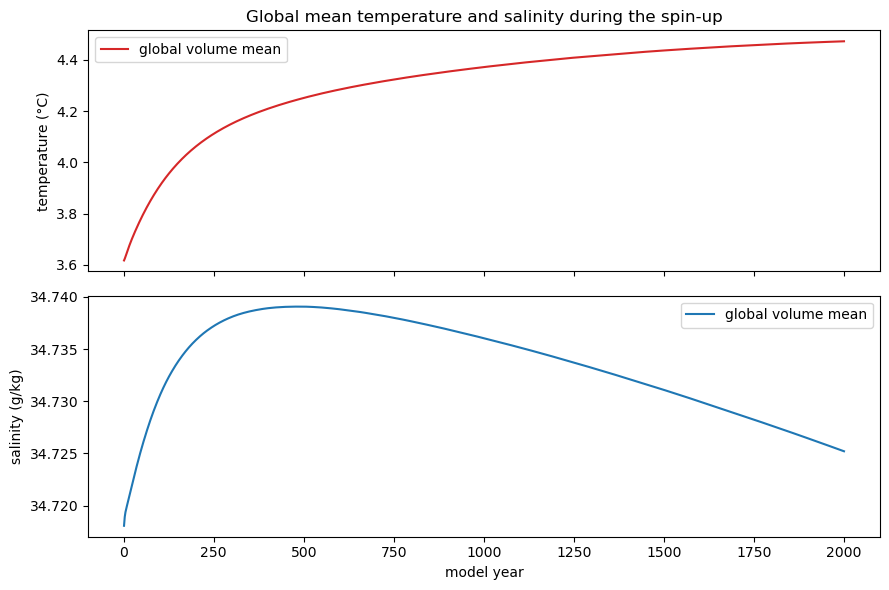

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axes[0].plot(yr_t, theta_mean, color="tab:red", label="global volume mean")
axes[0].set_ylabel("temperature (°C)")
axes[0].set_title("Global mean temperature and salinity during the spin-up")
axes[0].legend()
axes[1].plot(yr_s, salt_mean, color="tab:blue", label="global volume mean")
axes[1].set_ylabel("salinity (g/kg)")
axes[1].set_xlabel("model year")
axes[1].legend()
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "02_global_drift.png"), dpi=150)
plt.show()

Finally I look at the end of the run: the CFL numbers in the last monitor block (now that the currents are fully spun up), the pickup files saved for restarting, and the salinity restoring flux.

In [17]:
last_cfl = {}
for line in open(os.path.join(RUN, "output.txt")):
    if "%MON advcfl" in line or "%MON trAdv_CFL" in line:
        name = line.split("%MON")[1].split("=")[0].strip()
        last_cfl[name] = float(line.split("=")[1])
for name in sorted(last_cfl):
    print(f"{name:20s} {last_cfl[name]:.4f}")

pickups = sorted(glob.glob(os.path.join(RUN, "pickup.*.data")))
print("pickup files:", len(pickups), "| last:", os.path.basename(pickups[-1]) if pickups else "none")

flux, flux_iters, meta = rdmds(os.path.join(RUN, "surf_flux_annual"), iterations[-1], returnmeta=True)
srelax = flux[meta["fldlist"].index("SRELAX")]
area_ocean = rac * ocean
print(f"final year, global integral of SRELAX: {np.sum(srelax * area_ocean) / 1e6:.3f} tonnes of salt per second "
      f"(area mean {np.sum(srelax * area_ocean) / area_ocean.sum():.2e} g/m^2/s)")
clim_files = sorted(glob.glob(os.path.join(RUN, "srelax_clim100.*.data")))
print("100-year monthly SRELAX climatologies saved:", len(clim_files))

advcfl_W_hf_max      0.0293
advcfl_uvel_max      0.0396
advcfl_vvel_max      0.0257
advcfl_wvel_max      0.0259
trAdv_CFL_u_max      0.0396
trAdv_CFL_v_max      0.0315
trAdv_CFL_w_max      0.0293
pickup files: 20 | last: pickup.0000720000.data
final year, global integral of SRELAX: -550.122 tonnes of salt per second (area mean -1.59e-06 g/m^2/s)
100-year monthly SRELAX climatologies saved: 20


Global salinity is still falling at the end, in a straight line. To see why, I do a salt budget for the final year. I turn each global salt flux into the salinity trend it would cause, and compare with the measured trend: the total surface flux `SFLUX`, its restoring part `SRELAX`, and the rest, which is the virtual salt flux from EmPmR (EmPmR times the local surface salinity).

In [18]:
RHO_CONST = 1035.0                                    # rhoConst in the data file (kg/m^3)
SECONDS_PER_CENTURY = 100 * 360 * 86400.0
volume = np.sum(hfacc * drf[:, None, None] * rac[None, :, :])   # ocean volume (m^3)
sflux = flux[meta["fldlist"].index("SFLUX")]
total_salt_flux = np.sum(sflux * area_ocean)          # g/s, total surface salt flux
relax_salt_flux = np.sum(srelax * area_ocean)         # g/s, from restoring
empmr_salt_flux = total_salt_flux - relax_salt_flux   # g/s, virtual salt flux from EmPmR
implied_trend = total_salt_flux / (RHO_CONST * volume) * SECONDS_PER_CENTURY   # g/kg per century
print(f"ocean volume: {volume:.3e} m^3")
print(f"final-year global salt fluxes (tonnes/s): total {total_salt_flux / 1e6:+.1f}, "
      f"restoring {relax_salt_flux / 1e6:+.1f}, EmPmR virtual flux {empmr_salt_flux / 1e6:+.1f}")
implied_relax = relax_salt_flux / (RHO_CONST * volume) * SECONDS_PER_CENTURY
print(f"salinity trend implied by SFLUX (total):   {implied_trend:+.6f} g/kg per century")
print(f"salinity trend implied by SRELAX only:     {implied_relax:+.6f} g/kg per century")
print(f"salinity trend measured over the last {TREND_YEARS} years: {trend_per_century(yr_s, salt_mean, TREND_YEARS):+.6f} g/kg per century")

ocean volume: 1.323e+18 m^3
final-year global salt fluxes (tonnes/s): total +4013.1, restoring -550.1, EmPmR virtual flux +4563.2
salinity trend implied by SFLUX (total):   +0.009118 g/kg per century
salinity trend implied by SRELAX only:     -0.001250 g/kg per century
salinity trend measured over the last 500 years: -0.001176 g/kg per century


The measured trend matches the restoring flux alone, not `SFLUX`. So in this setup the large virtual salt flux from EmPmR does not change the total salt content. My reading: with a linear free surface and a real freshwater flux, the model also moves salt through the fixed surface with the surface vertical velocity (w times S), and that cancels the virtual flux in the global total. `SFLUX` leaves that term out, so it does not match the salt content here. The steady fall in salinity is the restoring slowly removing salt. I will test this reading directly in the step 7 salt check.